# Neuromap architecture 

We have already introduced **Infomap** as a graph clustering method that minimizes the description length of random-walk trajectories on a network. We now move to the **Neuromap** framework, which keeps the **same information-theoretic objective** (compression / code length) but changes how the partition is represented and optimized.

Neuromap implements a learnable (parametric) mapping that has the role to produce the community assignment.

This matters because classical Infomap directly searches over partitions (a discrete, combinatorial space), while Neuromap introduces a differentiable path: we learn parameters that output a *soft* partition, and we optimize those parameters to reduce an Infomap-like code length.



## Main Idea of Neuromap

In classical Infomap, we directly search for a **hard partition**:

$$
z(i) \in \{1, \dots, M\}
$$

meaning that each node `i` is assigned to exactly one community.

This is an optimization problem which is discrete and non-differentiable.

Neuromap replaces this direct discrete search with a **parametric, differentiable model**.

Instead of assigning a label directly, we learn a function:

$$
f_\theta(\cdot) \Rightarrow S \in [0,1]^{N \times M},
\quad
\sum_{m=1}^{M} S_{im} = 1
$$

Here:

- `N` = number of nodes  
- `M` = number of clusters  
- `S[i,m]` = probability (soft assignment) that node `i` belongs to cluster `m`

So each node is no longer assigned to a single module, but has a **probability distribution over modules**.

The matrix `S` is continuous and differentiable.  
This allows us to optimize parameters `θ` using gradient descent.

At the end of training, we can recover a hard partition by taking:

$$
z(i) = \arg\max_m S_{im}
$$



### Connection to Infomap

The idea is that Neuromap still minimizes an **information-theoretic code length**, inspired by the map equation used in Infomap.

The objective measures how well a partition compresses random-walk trajectories on the graph:

- If random walks mostly stay inside modules → short description length  
- If random walks frequently jump across modules → longer description length  

Similarly to how the map equation was defined. The model is trained so that the learned soft partition `S` produces **minimal code length**.
Ultimately neuromap learns a parametric mapping that produces a partition which maximizes that compression, making it **learnable with neural models**, allowing to use gradient based optimization and use different model architectures.

After training, we convert `S` into a hard partition (e.g., `argmax` per node) and evaluate it like any clustering.

### Implementation 
The goal of this project is not simply to run an existing Neuromap implementation,
but to **reconstruct the full framework* and study it in a controlled setting.
The implementation focuses on implementing the neuromap framework starting from the code snippets of the authors. 

In particular, we explicitly implement:

- Construction of the adjacency matrix `A`
- Computation of transition probabilities and stationary flow
- Derivation of the flow-based quantities entering the map equation
- Implementation of the differentiable information-theoretic loss
- Optimization via gradient descent

This ensures control and understanding on every component of the model.

By keeping fixed the loss fuction we compare a low level implementation of different models, studying how they behaves in a simplified environment.
We compare:

- **Linear model**
- **MLP**
- **GCN**


Because the objective and training procedure are identical across models,
any difference in performance can be attributed to the expressive power of the considered architecture.

This allows to understand whether performance is primarily driven by the information-theoretic objective itself or by the representational capacity of the model used to parameterize the partition.




### Why compare Linear vs MLP vs GCN

All three models output node-wise logits `Z ∈ R^{N×M}` and then:
$$
S = \mathrm{softmax}(Z / T)
$$
so they are directly comparable under the same loss. The difference is **what information each model is allowed to use** and **what inductive bias it imposes**.

### Linear model 

$$
Z = XW + b
$$
It uses only node features `X`, without passing information that isn't encoded in X.

It is the simplest parametric partitioner and it's main property is that it checks for whether the information-theoretic objective can extract structure from features alone.

We expect it to differentiate properly when features are already aligned with communities and fails when communities are primarily structural (graph-driven) rather than feature-driven.

### MLP (nonlinear feature model)

$$
Z = \mathrm{MLP}(X)
$$
Can represent nonlinear decision boundaries in feature space.

The MLP is included to determine whether performance gains over the Linear model arise purely from nonlinear transformations of node features. It is expected to improve the results the Linear model when the relationship between features and communities is nonlinear.

### 3) GCN (graph + feature model, message passing)
**Definition (conceptually):**
$$
H^{(0)} = X,\qquad
H^{(l+1)} = \sigma(\tilde{A}H^{(l)}W^{(l)}),\qquad
Z = H^{(L)}
$$

The GCN uses both node features and graph structure by aggregating information from each node’s neighbors, so connected nodes tend to learn similar representations. It is the natural architecture for this setting because the objective is based on random-walk flow, and the GCN can directly exploit the topology that governs how flow moves through the network. It is expected to perform well, although it can over-smooth and produce trivial partitions if not properly regularized.


Imports

In [1]:
import os
import time
import math
import random

import numpy as np
import networkx as nx   # used to load and visualize graphs and handle partitions
import matplotlib.pyplot as plt

import torch    # Pytorch will be extensively used 
import torch.nn as nn   # used to define neural networks (nn)
import torch.nn.functional as F  # important to define relevant functions 

from infomap import Infomap # Python wrapper of infomap algorithm
from sklearn.metrics import adjusted_mutual_info_score
from torch_geometric.data import Data


/home/riccorte/miniconda3/envs/neuromap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Import authors modules and functions

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
SRC_PATH = (PROJECT_ROOT / "neuromap" / "src").resolve()

if not SRC_PATH.exists():
    raise FileNotFoundError(f"Could not find neuromap/src at: {SRC_PATH}")

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("✓ neuromap/src added to sys.path")
print("  Using:", sys.path[0])


✓ neuromap/src added to sys.path
  Using: /home/riccorte/information_theory/InfoMap-Analysis/neuromap/src


In [3]:
import model
import training
import util
import pool
import plotting

print("✓ Successfully imported:")
print("  model   ->", model.__file__)
print("  training->", training.__file__)
print("  util    ->", util.__file__)
print("  pool    ->", pool.__file__)
print("  plotting->", plotting.__file__)


✓ Successfully imported:
  model   -> /home/riccorte/information_theory/InfoMap-Analysis/neuromap/src/model.py
  training-> /home/riccorte/information_theory/InfoMap-Analysis/neuromap/src/training.py
  util    -> /home/riccorte/information_theory/InfoMap-Analysis/neuromap/src/util.py
  pool    -> /home/riccorte/information_theory/InfoMap-Analysis/neuromap/src/pool.py
  plotting-> /home/riccorte/information_theory/InfoMap-Analysis/neuromap/src/plotting.py


In [4]:
import sys
sys.path.append(".")          # if neuromap_loss.py is in the same folder as the notebook
from neuromap_loss import NeuromapPooling


In [5]:
# We set a fixed seed for reproducibility
seed = 27

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch version:", torch.__version__)
print("Device:", device)
print("Seed:", seed)


Torch version: 2.10.0+cpu
Device: cpu
Seed: 27


### Dataset loader

We begin with the "Karate" network, usefful for debugging and visualization.


It is necessary to correctly prepare the dataset for the neuromap analysis, for each dataset we get:

- `n, m` = number of nodes and edges
- whether the graph is **directed** or **undirected**
- feature matrix shape `X ∈ R^{n×d}` (or note “no features” if not available)

These will be used to compute:
- adjacency matrix: `A ∈ R^{n×n}`
- feature matrix: `X ∈ R^{n×d}`
- cluster assignment matrix: `S ∈ R^{n×s}`

In [6]:
#G: networkx.Graph
G = nx.karate_club_graph()
#y_true: ground-truth labels 
# Ground truth: the "club" attribute is either 'Mr. Hi' or 'Officer'
# mapped to {0,1} in node order.
y_true = np.array([0 if G.nodes[i]["club"] == "Mr. Hi" else 1 for i in G.nodes()], dtype=int)

# Function used to understand the network we are working with
def summarize_graph(G, name="Graph"):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    directed = G.is_directed() # If the network is undirected, the Adjacency matrix is symmetric, the random walk treats neighbors equally in both directions. Flow is symmetric.
    weighted = any("weight" in data for _, _, data in G.edges(data=True))  # Tells if any node is weighted, this could lead to having transition probabilities higher for certain nodes.
    print(f"{name}:")
    print(f"  nodes (n) = {n}")
    print(f"  edges (m) = {m}")
    print(f"  directed  = {directed}")
    print(f"  weighted  = {weighted}")


summarize_graph(G, name="Karate")
print(G)
print("Ground-truth labels shape:", y_true.shape, "| unique labels:", np.unique(y_true))


Karate:
  nodes (n) = 34
  edges (m) = 78
  directed  = False
  weighted  = False
Graph named "Zachary's Karate Club" with 34 nodes and 78 edges
Ground-truth labels shape: (34,) | unique labels: [0 1]


### Adjacency matrix and Features

In this step we convert the graph into the tensor objects used by the model.

  graph_to_adj(G, weighted=True, directed=True) → A  
  Converts the graph G into the adjacency matrix A.  
  Output shape:  
  A ∈ R^{n×n}  

 make_features(A, X=None, mode="A" | "identity" | "given") → X 
  Builds the feature matrix X depending on the selected mode:
  - "A" → use the adjacency matrix as features (X = A)  
  - "identity" → use one-hot node identity features (X = I)  
  - "given" → use externally provided features  

If no node features are available, using X = A is consistent with the Neuromap paper, since structural information is then given directly in the input.

In [7]:
# This is used to create the adjagency matrix starting from the information of the network, 
# this will be used to compute the transition matrix and the flow matrix.
# It is fundamental since it is the mathematical object that encodes the graph.

def graph_to_adj(G, weighted, directed, device, dtype=torch.float32):

    #Convert a NetworkX graph to a dense adjacency matrix A (torch tensor).
    
    nodes = list(G.nodes())
    n = len(nodes)
    node_to_idx = {u: i for i, u in enumerate(nodes)}

    # Decide directedness
    if directed is None:
        directed = G.is_directed()

    A = torch.zeros((n, n), dtype=dtype, device=device)

    # Fill adjacency
    for u, v, data in G.edges(data=True):
        i = node_to_idx[u]
        j = node_to_idx[v]
        w = float(data.get("weight", 1.0)) if weighted else 1.0
        A[i, j] += w
        if not directed:
            A[j, i] += w  # mirror for undirected

    return A, nodes, node_to_idx



In [8]:

def make_features(A, X=None, mode="identity", device=device, dtype=torch.float32):

    # Create node feature matrix X.

    n = A.shape[0]

    if mode == "identity":  # each node gets a one-hot vector
        X_t = torch.eye(n, dtype=dtype, device=device)

    elif mode == "A":   # each node's feature = its row in adjacency matrix
        X_t = A.clone()

    elif mode == "given":
        if X is None:
            raise ValueError("Provide X when mode='given'.")
        return torch.as_tensor(X, device=device, dtype=dtype)
    

    return X_t


# Apply to Karate
USE_WEIGHTS = False  # True for weighted random walk

A, nodes, node_to_idx = graph_to_adj(
    G,
    weighted=USE_WEIGHTS,
    directed=None,
    device=device
)

# Choose features:
X = make_features(A, mode="A")

print("A shape:", tuple(A.shape))
print("X shape:", tuple(X.shape))
print("USE_WEIGHTS:", USE_WEIGHTS)
print("A.sum()/2:", A.sum().item()/2)

# Sanity Checks
# Karate is undirected, so A should be symmetric.
symmetry_error = torch.norm(A - A.T).item()
print("Symmetry error ||A - A^T||:", symmetry_error)

# Check non-negativity
print("A min/max:", A.min().item(), A.max().item())

# Check diagonal, should be all zeros
print("Diagonal:", A.diagonal())


A shape: (34, 34)
X shape: (34, 34)
USE_WEIGHTS: False
A.sum()/2: 78.0
Symmetry error ||A - A^T||: 0.0
A min/max: 0.0 1.0
Diagonal: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [9]:
print(A)


tensor([[0., 1., 1.,  ..., 1., 0., 0.],
        [1., 0., 1.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 0., 0.,  ..., 0., 1., 1.],
        [0., 0., 1.,  ..., 1., 0., 1.],
        [0., 0., 0.,  ..., 1., 1., 0.]])


In [10]:
# NeuromapPooling expects a sparse adjacency 
A_sp = A.to_sparse()

pool = NeuromapPooling(adj=A_sp)


### Computing the Visit Rates p

In this step we compute the stationary visit rates of a random walker on the network,
including teleportation, as mentioned in the Neuromap paper.

This gives us the node-level flow probabilities of trasnsition between one node and the other, that will be used in the information-theoretic objective.

We will compute the transition matrix T(A) and the visit rates p used to compute the neuromap loss.


### Update rule (power iteration with teleportation)

At each iteration:

$$
p^{(t+1)} = \alpha \frac{d_{in}}{w_{tot}} + (1 - \alpha) p^{(t)} T
$$

where:

- α = teleportation probability  
- d_in = in-degree (or in-strength) vector  
- w_tot = total edge weight in the graph  
- T = transition matrix  

Interpretation:

- With probability α, the walker teleports proportionally to node in-strength.
- With probability 1−α, the walker follows graph transitions.

We iterate until convergence (||p^{(t+1)} - p^{(t)}|| < tol).


In [11]:
# Random walk + teleportation: visit rates p

def compute_transition_matrix(A, eps=1e-12):
    """
    Row-normalize adjacency to get transition matrix T.
    T[i,j] = A[i,j] / sum_k A[i,k]  (outgoing normalization)

    Handles nodes with zero out-degree by leaving the row as zeros.
    """
    out_strength = A.sum(dim=1)  # (n,), sum of outgoing edge weights from each node
    T = torch.zeros_like(A)

    # Only normalize rows with positive out_strength
    mask = out_strength > eps
    T[mask] = A[mask] / out_strength[mask].unsqueeze(1) # Turns adjagency matrix into probabilities
    """T = torch.zeros_like(A)
    for i in range(A.shape[0]):
        s = A[i].sum()
        if s > 0:
            T[i] = A[i] / s"""
    return T, out_strength


def compute_visit_rates(A, alpha, max_iter, tol, eps=1e-12, verbose=False):
    """
    Compute stationary visit rates p using the Neuromap/PageRank-like update:
        p_{t+1} = alpha * (d_in / w_tot) + (1-alpha) * p_t * T

    """
    n = A.shape[0]
    T, out_strength = compute_transition_matrix(A, eps=eps)

    d_in = A.sum(dim=0)          # (n,) incoming strength
    w_tot = A.sum()              # total edge weight in the whole graph

    # Teleportation target distribution: proportional to in-strength
    # If w_tot == 0 we have an empty graph
    if w_tot == 0:
        raise ValueError("Graph has no edges.")
    v = d_in / w_tot

    # Initialize p with a uniform distribution
    p = torch.full((n,), 1.0/n, device=A.device, dtype=A.dtype) 

    # Power iteration
    for _ in range(max_iter):
        """p @ T gives the distribution after one normal random-walk step (no teleport).
            alpha * v injects teleport mass.
        """
        p_next = alpha * v + (1 - alpha) * (p @ T) # Power iter, with prob alpha you teleport, with 1- alpha you follow transition matrix
        # Convergence check
        if torch.norm(p_next - p, p=1) < tol:
            p = p_next
            break
        p = p_next

    return p, T, d_in, w_tot


# Run on Karate
p, T, d_in, w_tot = compute_visit_rates(A=A, alpha=0.15, max_iter=5000, tol=1e-12, verbose=False)

print("p shape:", tuple(p.shape))
print("T shape:", tuple(T.shape))
print("p sum:", p.sum().item())
print("Any NaN in p?", torch.isnan(p).any().item())
print("Any Inf in p?", torch.isinf(p).any().item())
# p tends to be roughly proportional to degree (with teleportation smoothing it).
deg = A.sum(dim=1)
c = (p / deg)[deg > 0].mean()
print("sum degrees:", deg.sum().item())
print("constant c:", c.item())
print("1/sum degrees:", (1.0 / deg.sum()).item())


p shape: (34,)
T shape: (34, 34)
p sum: 1.0
Any NaN in p? False
Any Inf in p? False
sum degrees: 156.0
constant c: 0.006410256493836641
1/sum degrees: 0.006410256493836641


### Flow matrix F

We build the **flow matrix** F, where F[i,j] is the long-run probability (per step) that the random surfer moves from node i to node j.


$$
F = \alpha \frac{A}{w_{tot}} + (1-\alpha)\,\mathrm{diag}(p)\,T
$$

- first term: **teleportation flow** (total mass α), distributed proportionally to link weights in A
- second term: **random-walk flow** (mass 1−α), equal to “how often we are at i” (p_i) times “probability to go i→j” (T_{ij})


In [12]:
def compute_flow_matrix(A, T, p, alpha=0.15):
    """
    Compute the flow matrix:
        F = (alpha / w_tot) * A  +  (1 - alpha) * diag(p) * T
    """
    
    w_tot = A.sum()

    teleport_flow = (alpha / w_tot) * A
    walk_flow = (1 - alpha) * (torch.diag(p) @ T)


    F = teleport_flow + walk_flow
    return F, w_tot


# Compute F for Karate 
F_mat, w_tot = compute_flow_matrix(A, T, p, alpha=0.15)

print("F shape:", tuple(F_mat.shape))
print("Any NaN in F?", torch.isnan(F_mat).any().item())
print("Any Inf in F?", torch.isinf(F_mat).any().item())
print("F min/max:", F_mat.min().item(), F_mat.max().item())

# Total flow per step should be ~1
print("Sum of all flows (should be ~1):", F_mat.sum().item())


F shape: (34, 34)
Any NaN in F? False
Any Inf in F? False
F min/max: 0.0 0.006410257425159216
Sum of all flows (should be ~1): 1.0


### Neuromap loss in PyTorch

This is the core of the implementation: given the flow matrix** F, visit rates p, and soft cluster assignments S,
we compute the Neuromap information-theoretic objective as a **single differentiable scalar**.

As we said, Neuromap compresses flow at the **module level** by aggregating node-to-node flow through S:

- C = S.T @ F @ S  → module-to-module flow matrix (shape (M, M))

From C we compute the quantities used in the paper (notation may vary, but conceptually):

- q : total probability of **exiting modules** (inter-module flow)
- q_m : exit probability of each module m
- p_m : total probability mass **inside** module m (node visits assigned to m)
- m_exit : module exit distribution derived from q_m

During training, it is possible to omit the constant term that depends only on p (it does not affect gradients w.r.t. S)


In [13]:
def _log2(x):
    return torch.log(x) / math.log(2.0)

def neuromap_loss(F, p, S, eps=1e-12, omit_constant_term=True):
    """
    Neuromap loss = differentiable map equation (Eq. 3 in the paper).

    Inputs:
      F: (n,n) flow matrix
      p: (n,) node visit rates, sums to 1
      S: (n,s) soft assignments (rows sum to 1)

    Returns:
      loss (torch tensor)
    """
    n = F.shape[0]
    s = S.shape[1]

    # Stabilize S 
    S_safe = torch.clamp(S, min=eps)
    S_safe = S_safe / S_safe.sum(dim=1, keepdim=True)

    # Pool node flow to cluster flow: C = S^T F S
    C = S_safe.T @ F @ S_safe   # (s,s)

    # Diagonal of C (within-cluster flow)
    diagC = torch.diag(C)       # (s,)

    # q = 1 - tr(C)
    q = 1.0 - diagC.sum()

    # qm = C 1_s - diag(C)  (row sums minus diagonal)
    qm = C.sum(dim=1) - diagC

    # mexit = (1_s^T C)^T - diag(C) (column sums minus diagonal)
    mexit = C.sum(dim=0) - diagC

    # pm = qm + 1_s^T C (qm + column sums)
    pm = qm + C.sum(dim=1)

    # Clamp before logs to avoid log(0)
    q_c     = torch.clamp(q,     min=eps)
    qm_c    = torch.clamp(qm,    min=eps)
    mexit_c = torch.clamp(mexit, min=eps)
    pm_c    = torch.clamp(pm,    min=eps)
    p_c     = torch.clamp(p,     min=eps)

    # Eq. (3): scalar form (summing the vector terms)
    loss = (
        q_c * _log2(q_c)
        - torch.sum(qm_c * _log2(qm_c))
        - torch.sum(mexit_c * _log2(mexit_c))
        + torch.sum(pm_c * _log2(pm_c))
    )

    # Constant term: -(p log2 p) * 1_n = -sum_u p_u log2 p_u
    # Paper says it can be omitted during optimisation because it only depends on p. 
    if not omit_constant_term:
        loss = loss - torch.sum(p_c * _log2(p_c))

    return loss


def harden(S):  # we choose the maximum a posteriori (MAP) cluster:
    """Convert soft assignments to hard labels via argmax."""
    return torch.argmax(S, dim=1)

def count_used_clusters(labels):
    """How many clusters are actually used in the hard assignment."""
    return torch.unique(labels).numel()


### Assignment Matrix S from Models

All models share a common interface:

forward(A, X) → logits → S

Each model outputs node-level logits $Z \in \mathbb{R}^{n \times s}$, which are converted into soft assignments via

$S = \mathrm{softmax}(Z)$


Linear model: $Z = X W$
MLP model: $Z = \mathrm{MLP}(X)$
GNN (2-layer GCN): $Z = \mathrm{GNN}(A, X)$


In [14]:
class LinearNeuromap(torch.nn.Module):
    def __init__(self, in_dim, num_clusters, dropout=0.0):
        super().__init__()
        self.linear = torch.nn.Linear(in_dim, num_clusters)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, A, X):
        X = self.dropout(X)
        logits = self.linear(X)
        return logits


In [15]:
class MLPNeuromap(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, num_clusters, dropout=0.0):
        super().__init__()
        self.fc1 = torch.nn.Linear(in_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, num_clusters)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, A, X):
        h = torch.relu(self.fc1(X))
        h = self.dropout(h)
        logits = self.fc2(h)
        return logits


In [16]:
def normalize_adjacency(A, eps=1e-12):
    I = torch.eye(A.shape[0], device=A.device)
    A_hat = A + I
    deg = A_hat.sum(dim=1)
    deg_inv_sqrt = 1.0 / torch.sqrt(torch.clamp(deg, min=eps))

    # Efficient symmetric normalization
    A_norm = deg_inv_sqrt.unsqueeze(1) * A_hat * deg_inv_sqrt.unsqueeze(0)
    return A_norm


In [17]:
class GCNNeuromap(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, num_clusters):
        super().__init__()
        self.fc1 = torch.nn.Linear(in_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, num_clusters)

    def forward(self, A_norm, X):
        h = torch.relu(A_norm @ self.fc1(X))
        logits = self.fc2(h)      # <-- no second A_norm
        return logits


### Training loop ( Linear, MLP and GCN)

This is the optimization routine used for all model variants.
The only component that changes between experiments is the model class
(LinearNeuromap, MLP, or GCN). The training logic is identical.

It uses different restarts to exploit the stochastic nature of the sistem.

A temperature schedule is applied to the logits before softmax:

$S = \mathrm{softmax}(Z / T)$

The temperature decreases during training (linear or exponential decay).

High temperature → softer assignments  
Low temperature → sharper, near-discrete assignments  

This stabilizes early training and gradually encourages hard clustering.



In [18]:
# Choose max number of clusters s
n = A.shape[0]
s = int(round(math.sqrt(n)))  # paper-style choice: s ~ sqrt(n)
s = max(s, 2)                 # at least 2 clusters


In [19]:
def labels_to_S(labels, num_clusters=None, device=None):
    """
    Convert integer labels (shape N,) to one-hot assignment matrix S (N x K).
    """
    labels = torch.as_tensor(labels, dtype=torch.long, device=device)

    if num_clusters is None:
        num_clusters = int(torch.unique(labels).numel())

    N = labels.numel()
    S = torch.zeros((N, num_clusters), device=labels.device)
    S[torch.arange(N, device=labels.device), labels] = 1.0

    return S


In [20]:
im = Infomap("--silent")
im.add_networkx_graph(G)
im.run()

# map node -> module
labels_infomap = np.zeros(n, dtype=int)
for node in im.tree:
    if node.is_leaf:
        labels_infomap[node.node_id] = node.module_id  # module id from infomap

# relabel modules to 0..K-1
uniq = np.unique(labels_infomap)
remap = {old:i for i,old in enumerate(uniq)}
labels_infomap = np.array([remap[x] for x in labels_infomap])


In [21]:
# Linear Neuromap


def set_all_seeds(seed: int, deterministic: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.use_deterministic_algorithms(True)
        torch.backends.cudnn.benchmark = False

def temp_schedule(epoch, epochs, temp_start=2.0, temp_end=0.7, mode="exp"):
    if epochs <= 1:
        return temp_end
    if mode == "linear":
        t = epoch / (epochs - 1)
        return temp_start + t * (temp_end - temp_start)
    elif mode == "exp":
        r = (temp_end / temp_start) ** (1.0 / (epochs - 1))
        return temp_start * (r ** epoch)
    else:
        raise ValueError("mode must be 'linear' or 'exp'")

@torch.no_grad()
def num_modules_from_S(S):
    labels = torch.argmax(S, dim=1)
    return int(torch.unique(labels).numel())

def train_linear_one_run(
    in_dim, num_clusters,
    F, p, A, X,
    lr=1e-1, epochs=3000, patience=200, seed=27,
    temp_start=2.0, temp_end=0.7, temp_decay="exp",
    log_every=500, track_clusters_every=500,
    omit_constant_term=True,
    select_by_full_codelength=False,   # if True, pick best epoch by full codelength
):
    """
    Trains a FRESH LinearNeuromap model from scratch for one seed.
    Returns best_S and history. Uses YOUR neuromap_loss.
    """
    set_all_seeds(seed, deterministic=True)

    model = LinearNeuromap(in_dim=in_dim, num_clusters=num_clusters).to(X.device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best = {"score": float("inf"), "epoch": -1, "S": None}
    no_improve = 0
    history = {"loss_train": [], "score": [], "M_used": [], "best_epoch": None, "best_score": None, "time_sec": None}

    t0 = time.time()

    for epoch in range(epochs):
        model.train()
        opt.zero_grad()

        logits = model(A, X)
        temp = temp_schedule(epoch, epochs, temp_start, temp_end, mode=temp_decay)
        S = torch.softmax(logits / temp, dim=1)

        # Training objective 
        L_train = neuromap_loss(F, p, S, omit_constant_term=omit_constant_term)
        L_train.backward()
        opt.step()

        L_train_val = float(L_train.item())
        history["loss_train"].append(L_train_val)

        # Selection score 
        if select_by_full_codelength:
            with torch.no_grad():
                score = float(neuromap_loss(F, p, S, omit_constant_term=False).item())
        else:
            score = L_train_val

        history["score"].append(score)

        if (epoch % track_clusters_every == 0) or (epoch == epochs - 1):
            history["M_used"].append((epoch, num_modules_from_S(S)))

        if score < best["score"] - 1e-12:
            best = {"score": score, "epoch": epoch, "S": S.detach().clone()}
            no_improve = 0
        else:
            no_improve += 1

        if (epoch % log_every == 0) or (epoch == epochs - 1):
            print(f"epoch {epoch:4d} | temp {temp:.3f} | train {L_train_val:.6f} | best_score {best['score']:.6f} | no_improve {no_improve}")

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best epoch {best['epoch']})")
            break

    history["time_sec"] = time.time() - t0
    history["best_epoch"] = best["epoch"]
    history["best_score"] = best["score"]

    return best["S"], history

@torch.no_grad()
def full_codelength_your_loss(F, p, S):
    return float(neuromap_loss(F, p, S, omit_constant_term=False).item())


Reference full codelengths:
  L(Infomap):     4.311792373657227 | modules: 3
  L(one cluster): 4.704422950744629
epoch    0 | temp 2.000 | train 1.388928 | best_score 1.388928 | no_improve 0
epoch  500 | temp 1.679 | train -0.294703 | best_score -0.294703 | no_improve 0
epoch 1000 | temp 1.409 | train -0.295070 | best_score -0.295070 | no_improve 0
epoch 1500 | temp 1.183 | train -0.295395 | best_score -0.295395 | no_improve 0
epoch 2000 | temp 0.993 | train -0.295507 | best_score -0.295507 | no_improve 1
epoch 2500 | temp 0.834 | train -0.295519 | best_score -0.295519 | no_improve 0
epoch 2999 | temp 0.700 | train -0.295521 | best_score -0.295521 | no_improve 61

Restart 1/5 | seed=27 | best_train=-0.295521 | full=4.408901 | |M|=2 | time=10.15s
epoch    0 | temp 2.000 | train 1.389940 | best_score 1.389940 | no_improve 0
epoch  500 | temp 1.679 | train -0.294811 | best_score -0.294811 | no_improve 0
epoch 1000 | temp 1.409 | train -0.295070 | best_score -0.295070 | no_improve 0
epoch 

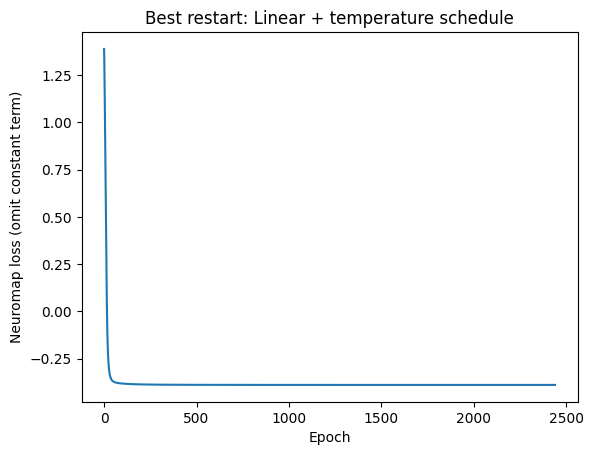

In [22]:
# Linear Neuromap baseline (infomap)

S_im = labels_to_S(labels_infomap, num_clusters=len(np.unique(labels_infomap)), device=device)
L_im_full = full_codelength_your_loss(F_mat, p, S_im)

S_one = torch.ones((n, 1), device=device)
L_one_full = full_codelength_your_loss(F_mat, p, S_one)

print("Reference full codelengths:")
print("  L(Infomap):    ", L_im_full, "| modules:", len(np.unique(labels_infomap)))
print("  L(one cluster):", L_one_full)

RESTARTS = 5
base_seed = 27

best_overall = {"seed": None, "L_train": float("inf"), "L_full": float("inf"), "M_used": None, "S": None, "hist": None}

for r in range(RESTARTS):
    run_seed = base_seed + r
    best_S, hist = train_linear_one_run(
        in_dim=X.shape[1],
        num_clusters=s,
        F=F_mat, p=p, A=A, X=X,
        lr=1e-1,
        epochs=3000,
        patience=200,
        seed=run_seed,
        temp_start=2.0,
        temp_end=0.7,
        temp_decay="exp",
        log_every=500,
        track_clusters_every=500,
        omit_constant_term=True,
        select_by_full_codelength=False,  
    )

    L_train = hist["best_score"]
    L_full = full_codelength_your_loss(F_mat, p, best_S)
    M_used = num_modules_from_S(best_S)

    print(f"\nRestart {r+1}/{RESTARTS} | seed={run_seed} | best_train={L_train:.6f} | full={L_full:.6f} | |M|={M_used} | time={hist['time_sec']:.2f}s")

    if L_full < best_overall["L_full"]:
        best_overall.update({"seed": run_seed, "L_train": L_train, "L_full": L_full, "M_used": M_used, "S": best_S, "hist": hist})

# AMI vs ground truth (only if y_true is available)
labels_linear_best = torch.argmax(best_overall["S"], dim=1).detach().cpu().numpy()
AMI_linear = float(adjusted_mutual_info_score(y_true, labels_linear_best)) if y_true is not None else None

print("\n==== Best over restarts (Linear) ====")
print("Seed:", best_overall["seed"])
print("Best training score:", best_overall["L_train"])
print("Best full codelength:", best_overall["L_full"])
print("|M| used:", best_overall["M_used"])
print("Compare to Infomap full:", L_im_full)
print("Compare to one-cluster full:", L_one_full)
print("AMI vs ground truth:", AMI_linear)

plt.figure()
plt.plot(best_overall["hist"]["loss_train"])
plt.xlabel("Epoch")
plt.ylabel("Neuromap loss (omit constant term)")
plt.title("Best restart: Linear + temperature schedule")
plt.show()


In [23]:
def train_neuromap_one_run(
    model,
    F, p, A, X,
    lr=5e-1, epochs=4000, patience=300, seed=27,
    temp_start=2.0, temp_end=0.7, temp_decay="exp",
    log_every=500, track_clusters_every=500,
    omit_constant_term=True,
    select_by_full_codelength=False,
):
    """
    Generic trainer for Neuromap models that output logits.
    Applies softmax(logits/temp) and optimizes your neuromap_loss(F,p,S).
    Returns best_S and history.
    """
    set_all_seeds(seed, deterministic=True)

    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best = {"score": float("inf"), "epoch": -1, "S": None}
    no_improve = 0
    history = {"loss_train": [], "score": [], "M_used": [], "best_epoch": None, "best_score": None, "time_sec": None}

    t0 = time.time()

    for epoch in range(epochs):
        model.train()
        opt.zero_grad()

        logits = model(A, X)
        temp = temp_schedule(epoch, epochs, temp_start, temp_end, mode=temp_decay)
        S = torch.softmax(logits / temp, dim=1)

        L_train = neuromap_loss(F, p, S, omit_constant_term=omit_constant_term)
        L_train.backward()
        opt.step()

        L_train_val = float(L_train.item())
        history["loss_train"].append(L_train_val)

        # selection score
        if select_by_full_codelength:
            with torch.no_grad():
                score = float(neuromap_loss(F, p, S, omit_constant_term=False).item())
        else:
            score = L_train_val
        history["score"].append(score)

        if (epoch % track_clusters_every == 0) or (epoch == epochs - 1):
            history["M_used"].append((epoch, num_modules_from_S(S)))

        if score < best["score"] - 1e-12:
            best = {"score": score, "epoch": epoch, "S": S.detach().clone()}
            no_improve = 0
        else:
            no_improve += 1

        if (epoch % log_every == 0) or (epoch == epochs - 1):
            print(f"epoch {epoch:4d} | temp {temp:.3f} | train {L_train_val:.6f} | best_score {best['score']:.6f} | no_improve {no_improve}")

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best epoch {best['epoch']})")
            break

    history["time_sec"] = time.time() - t0
    history["best_epoch"] = best["epoch"]
    history["best_score"] = best["score"]

    return best["S"], history


Reference full codelengths:
  L(Infomap):      4.311792373657227 | modules: 3
  L(one cluster):  4.704422950744629
epoch    0 | temp 2.000 | train 1.390773 | best_score 1.390773 | no_improve 0
epoch  500 | temp 1.754 | train 0.000132 | best_score 0.000130 | no_improve 1
epoch 1000 | temp 1.538 | train 0.000019 | best_score 0.000018 | no_improve 6
epoch 1500 | temp 1.349 | train 0.000006 | best_score 0.000000 | no_improve 122
Early stopping at epoch 1678 (best epoch 1378)

Restart 1/5 | seed=27 | best_train=0.000000 | full=4.704423 | |M|=1 | time=4.89s
epoch    0 | temp 2.000 | train 1.391018 | best_score 1.391018 | no_improve 0
epoch  500 | temp 1.754 | train 0.000150 | best_score 0.000150 | no_improve 0
epoch 1000 | temp 1.538 | train 0.000020 | best_score 0.000019 | no_improve 1
epoch 1500 | temp 1.349 | train 0.000006 | best_score 0.000002 | no_improve 55
epoch 2000 | temp 1.183 | train 0.000003 | best_score 0.000000 | no_improve 255
Early stopping at epoch 2045 (best epoch 1745)

R

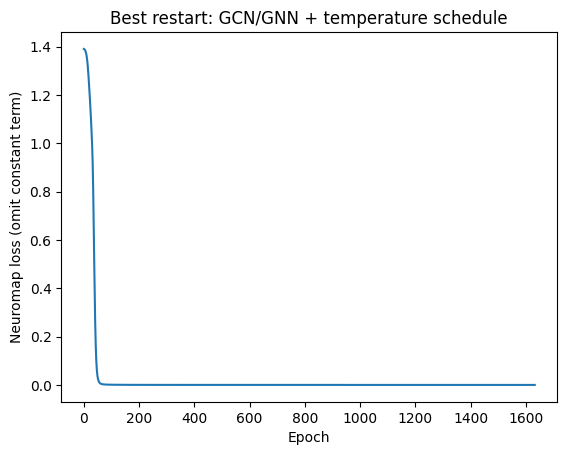

In [24]:
# GCN/GNN Neuromap

# Baselines Infomap same as linear
S_im = labels_to_S(labels_infomap, num_clusters=len(np.unique(labels_infomap)), device=device)
L_im_full = full_codelength_your_loss(F_mat, p, S_im)

S_one = torch.ones((n, 1), device=device)
L_one_full = full_codelength_your_loss(F_mat, p, S_one)

print("Reference full codelengths:")
print("  L(Infomap):     ", L_im_full, "| modules:", len(np.unique(labels_infomap)))
print("  L(one cluster): ", L_one_full)

A_norm = normalize_adjacency(A)

RESTARTS = 5
base_seed = 27

best_overall_gcn = {
    "seed": None,
    "L_train": float("inf"),
    "L_full": float("inf"),
    "M_used": None,
    "S": None,
    "hist": None,
}

for r in range(RESTARTS):
    run_seed = base_seed + r
    set_all_seeds(run_seed, deterministic=True)   
    # Fresh GCN model each restart (assumes GCNNeuromap exists)
    model = GCNNeuromap(in_dim=X.shape[1], hidden_dim=32, num_clusters=s).to(device)

    best_S, hist = train_neuromap_one_run(
        model=model,
        F=F_mat, p=p, A=A_norm, X=X,
        lr=5e-3,
        epochs=4000,
        patience=300,
        seed=run_seed,
        temp_start=2.0,
        temp_end=0.7,
        temp_decay="exp",
        omit_constant_term=True,
        select_by_full_codelength=False,   # keep consistent with training objective
        log_every=500,
        track_clusters_every=500,
    )

    L_train = hist["best_score"]
    L_full = full_codelength_your_loss(F_mat, p, best_S)
    M_used = num_modules_from_S(best_S)

    print(
        f"\nRestart {r+1}/{RESTARTS} | seed={run_seed} | "
        f"best_train={L_train:.6f} | full={L_full:.6f} | |M|={M_used} | time={hist['time_sec']:.2f}s"
    )

    if L_full < best_overall_gcn["L_full"]:
        best_overall_gcn.update({
            "seed": run_seed,
            "L_train": L_train,
            "L_full": L_full,
            "M_used": M_used,
            "S": best_S,
            "hist": hist
        })

labels_gcn_best = torch.argmax(best_overall_gcn["S"], dim=1).detach().cpu().numpy()
AMI_gcn = float(adjusted_mutual_info_score(y_true, labels_gcn_best)) if y_true is not None else None

print("\n==== Best over restarts (GCN/GNN) ====")
print("Seed:", best_overall_gcn["seed"])
print("Best training score:", best_overall_gcn["L_train"])
print("Best full codelength:", best_overall_gcn["L_full"])
print("|M| used:", best_overall_gcn["M_used"])
print("Compare to Infomap full:", L_im_full)
print("Compare to one-cluster full:", L_one_full)
print("AMI vs ground truth:", AMI_gcn)

plt.figure()
plt.plot(best_overall_gcn["hist"]["loss_train"])
plt.xlabel("Epoch")
plt.ylabel("Neuromap loss (omit constant term)")
plt.title("Best restart: GCN/GNN + temperature schedule")
plt.show()


Reference full codelengths:
  L(Infomap):      4.311792373657227 | modules: 3
  L(one cluster):  4.704422950744629
epoch    0 | temp 2.000 | train 1.390939 | best_score inf | no_improve 0
epoch  500 | temp 1.679 | train 0.000000 | best_score 0.000000 | no_improve 0
epoch 1000 | temp 1.409 | train 0.000000 | best_score 0.000000 | no_improve 15
Early stopping at epoch 1278 (best epoch 1078)

Restart 1/5 | seed=27 | best_train=0.000000 | full=4.704422 | |M|=1 | time=2.97s
epoch    0 | temp 2.000 | train 1.391020 | best_score inf | no_improve 0
epoch  500 | temp 1.679 | train 0.000000 | best_score 0.000000 | no_improve 2
epoch 1000 | temp 1.409 | train 0.000000 | best_score 0.000000 | no_improve 106
Early stopping at epoch 1093 (best epoch 893)

Restart 2/5 | seed=28 | best_train=0.000000 | full=4.704422 | |M|=1 | time=4.62s
epoch    0 | temp 2.000 | train 1.389951 | best_score inf | no_improve 0
epoch  500 | temp 1.679 | train 0.000000 | best_score 0.000000 | no_improve 3
Early stopping a

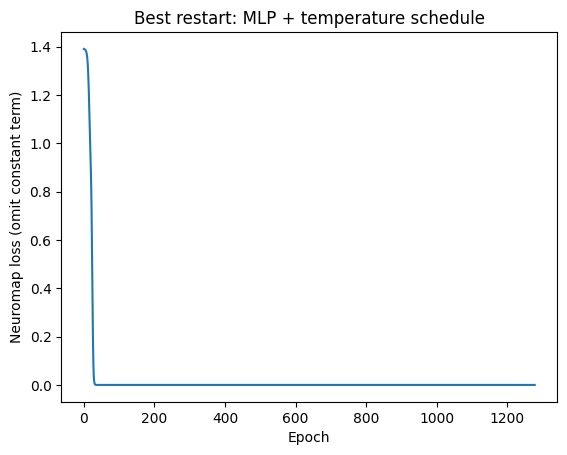

In [25]:
# MLP Neuromap baseline 
# Baselines Infomap 
S_im = labels_to_S(labels_infomap, num_clusters=len(np.unique(labels_infomap)), device=device)
L_im_full = full_codelength_your_loss(F_mat, p, S_im)

S_one = torch.ones((n, 1), device=device)
L_one_full = full_codelength_your_loss(F_mat, p, S_one)

print("Reference full codelengths:")
print("  L(Infomap):     ", L_im_full, "| modules:", len(np.unique(labels_infomap)))
print("  L(one cluster): ", L_one_full)

USE_LEARNABLE_X = True
EMB_DIM = 32

class LearnableFeatures(nn.Module):
    def __init__(self, n_nodes, emb_dim=32):
        super().__init__()
        self.emb = nn.Embedding(n_nodes, emb_dim)
        nn.init.normal_(self.emb.weight, mean=0.0, std=0.1)

    def forward(self):
        return self.emb.weight

RESTARTS = 5
base_seed = 27

best_overall_mlp = {
    "seed": None,
    "L_train": float("inf"),
    "L_full": float("inf"),
    "M_used": None,
    "S": None,
    "hist": None,
}

for r in range(RESTARTS):
    run_seed = base_seed + r

    set_all_seeds(run_seed, deterministic=True)

    # Choose features for this run
    if USE_LEARNABLE_X:
        feat = LearnableFeatures(n_nodes=n, emb_dim=EMB_DIM).to(device)
        X_run = feat()  # (n, EMB_DIM)
        in_dim_run = EMB_DIM
    else:
        feat = None
        X_run = X
        in_dim_run = X.shape[1]

    # Fresh MLP model
    model = MLPNeuromap(in_dim=in_dim_run, hidden_dim=32, num_clusters=s).to(device)

    # Optimizer: include feat params if using learnable embeddings
    params = list(model.parameters()) + (list(feat.parameters()) if feat is not None else [])
    opt = torch.optim.Adam(params, lr=1e-2)

    best = {"score": float("inf"), "epoch": -1, "S": None}
    no_improve = 0
    hist = {"loss_train": [], "score": [], "M_used": [], "best_epoch": None, "best_score": None, "time_sec": None}
    t0 = time.time()

    for epoch in range(3000):
        model.train()
        opt.zero_grad()

        # refresh X if learnable
        if feat is not None:
            X_run = feat()

        logits = model(A, X_run)  # MLP ignores A but we keep unified interface
        temp = temp_schedule(epoch, 3000, temp_start=2.0, temp_end=0.7, mode="exp")
        S = torch.softmax(logits / temp, dim=1)

        L_train = neuromap_loss(F_mat, p, S, omit_constant_term=True)
        L_train.backward()
        opt.step()

        L_train_val = float(L_train.item())
        hist["loss_train"].append(L_train_val)
        hist["score"].append(L_train_val)

        if (epoch % 500 == 0) or (epoch == 3000 - 1):
            hist["M_used"].append((epoch, num_modules_from_S(S)))
            print(f"epoch {epoch:4d} | temp {temp:.3f} | train {L_train_val:.6f} | best_score {best['score']:.6f} | no_improve {no_improve}")

        if L_train_val < best["score"] - 1e-12:
            best = {"score": L_train_val, "epoch": epoch, "S": S.detach().clone()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= 200:
            print(f"Early stopping at epoch {epoch} (best epoch {best['epoch']})")
            break

    hist["time_sec"] = time.time() - t0
    hist["best_epoch"] = best["epoch"]
    hist["best_score"] = best["score"]

    best_S = best["S"]
    L_train = hist["best_score"]
    L_full = full_codelength_your_loss(F_mat, p, best_S)
    M_used = num_modules_from_S(best_S)

    print(
        f"\nRestart {r+1}/{RESTARTS} | seed={run_seed} | "
        f"best_train={L_train:.6f} | full={L_full:.6f} | |M|={M_used} | time={hist['time_sec']:.2f}s"
    )

    if L_full < best_overall_mlp["L_full"]:
        best_overall_mlp.update({
            "seed": run_seed,
            "L_train": L_train,
            "L_full": L_full,
            "M_used": M_used,
            "S": best_S,
            "hist": hist
        })

labels_mlp_best = torch.argmax(best_overall_mlp["S"], dim=1).detach().cpu().numpy()
AMI_mlp = float(adjusted_mutual_info_score(y_true, labels_mlp_best)) if y_true is not None else None

print("\n==== Best over restarts (MLP) ====")
print("Seed:", best_overall_mlp["seed"])
print("Best training score:", best_overall_mlp["L_train"])
print("Best full codelength:", best_overall_mlp["L_full"])
print("|M| used:", best_overall_mlp["M_used"])
print("Compare to Infomap full:", L_im_full)
print("Compare to one-cluster full:", L_one_full)
print("AMI vs ground truth:", AMI_mlp)

plt.figure()
plt.plot(best_overall_mlp["hist"]["loss_train"])
plt.xlabel("Epoch")
plt.ylabel("Neuromap loss (omit constant term)")
plt.title("Best restart: MLP + temperature schedule")
plt.show()


For each metho we evaluate the final hard partition and record:

- $|M|$ number of used clusters (after hardening)
- $L_{hard}$ code length computed on the hard partition using a hard map-equation implementation (ours or external)
- runtime in seconds
- where ground truth is available: AMI

The key point is that Neuromap models are trained with a soft assignment matrix $S$, but evaluation is always done on the hardened labels
$z(i) = \arg\max_m S_{im}$ to make the comparison consistent with Infomap.


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def compute_pos(G, seed=42, layout="kamada_kawai"):
    if layout == "spring":
        pos = nx.spring_layout(G, seed=seed)
    elif layout == "spectral":
        pos = nx.spectral_layout(G)
    else:
        pos = nx.kamada_kawai_layout(G)

    # center + normalize
    nodes = list(G.nodes())
    P = np.array([pos[v] for v in nodes], dtype=float)
    P -= P.mean(axis=0, keepdims=True)
    m = np.max(np.abs(P))
    if m > 0:
        P /= m

    return {v: (float(P[i,0]), float(P[i,1])) for i, v in enumerate(nodes)}

def draw_nodes_only(G, labels=None, title="", pos=None, ax=None,
                    node_size=400, with_labels=True):

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))

    ax.clear()
    ax.set_title(title)
    ax.axis("off")
    ax.set_aspect("equal")

    if pos is None:
        pos = compute_pos(G)

    if labels is None:
        node_color = "lightgray"
    else:
        labels = np.asarray(labels)
        uniq = np.unique(labels)
        mapping = {lab: i for i, lab in enumerate(uniq)}
        node_color = np.array([mapping[labels[i]] for i in range(len(labels))])

    nx.draw_networkx_nodes(
        G, pos,
        ax=ax,
        node_color=node_color,
        cmap=plt.cm.tab20,
        node_size=node_size
    )

    if with_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=10)

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)

    return pos


## Results on Karate — Partition Comparison

The Linear Neuromap model is the only architecture that recovers a non-trivial partition on the Karate network.  
It finds $|M| = 3$ modules and achieves a full codelength essentially identical to Infomap, indicating that the learned partition compresses random-walk flow almost optimally.  
In contrast, both the MLP and the GCN collapse to the trivial one-cluster solution ($|M| = 1$), yielding the one-cluster codelength and zero agreement with ground truth.

This behavior suggests that, in the simplified implementation used here, higher-capacity models are more prone to trivial collapse.  
Without additional stabilization or regularization mechanisms, the differentiable Neuromap objective alone is not sufficient to prevent trivial solutions in the MLP and GCN cases, especially on a small graph like Karate.

- One-cluster codelength: 4.70442, M=2
- Infomap codelength: 4.31179, M=3
- Neuromap Linear codelength: 4.31496, M=3
- Neuromap MLP codelength: 4.70442, M=1
- Neuromap GCN codelength: 4.70442, M=1

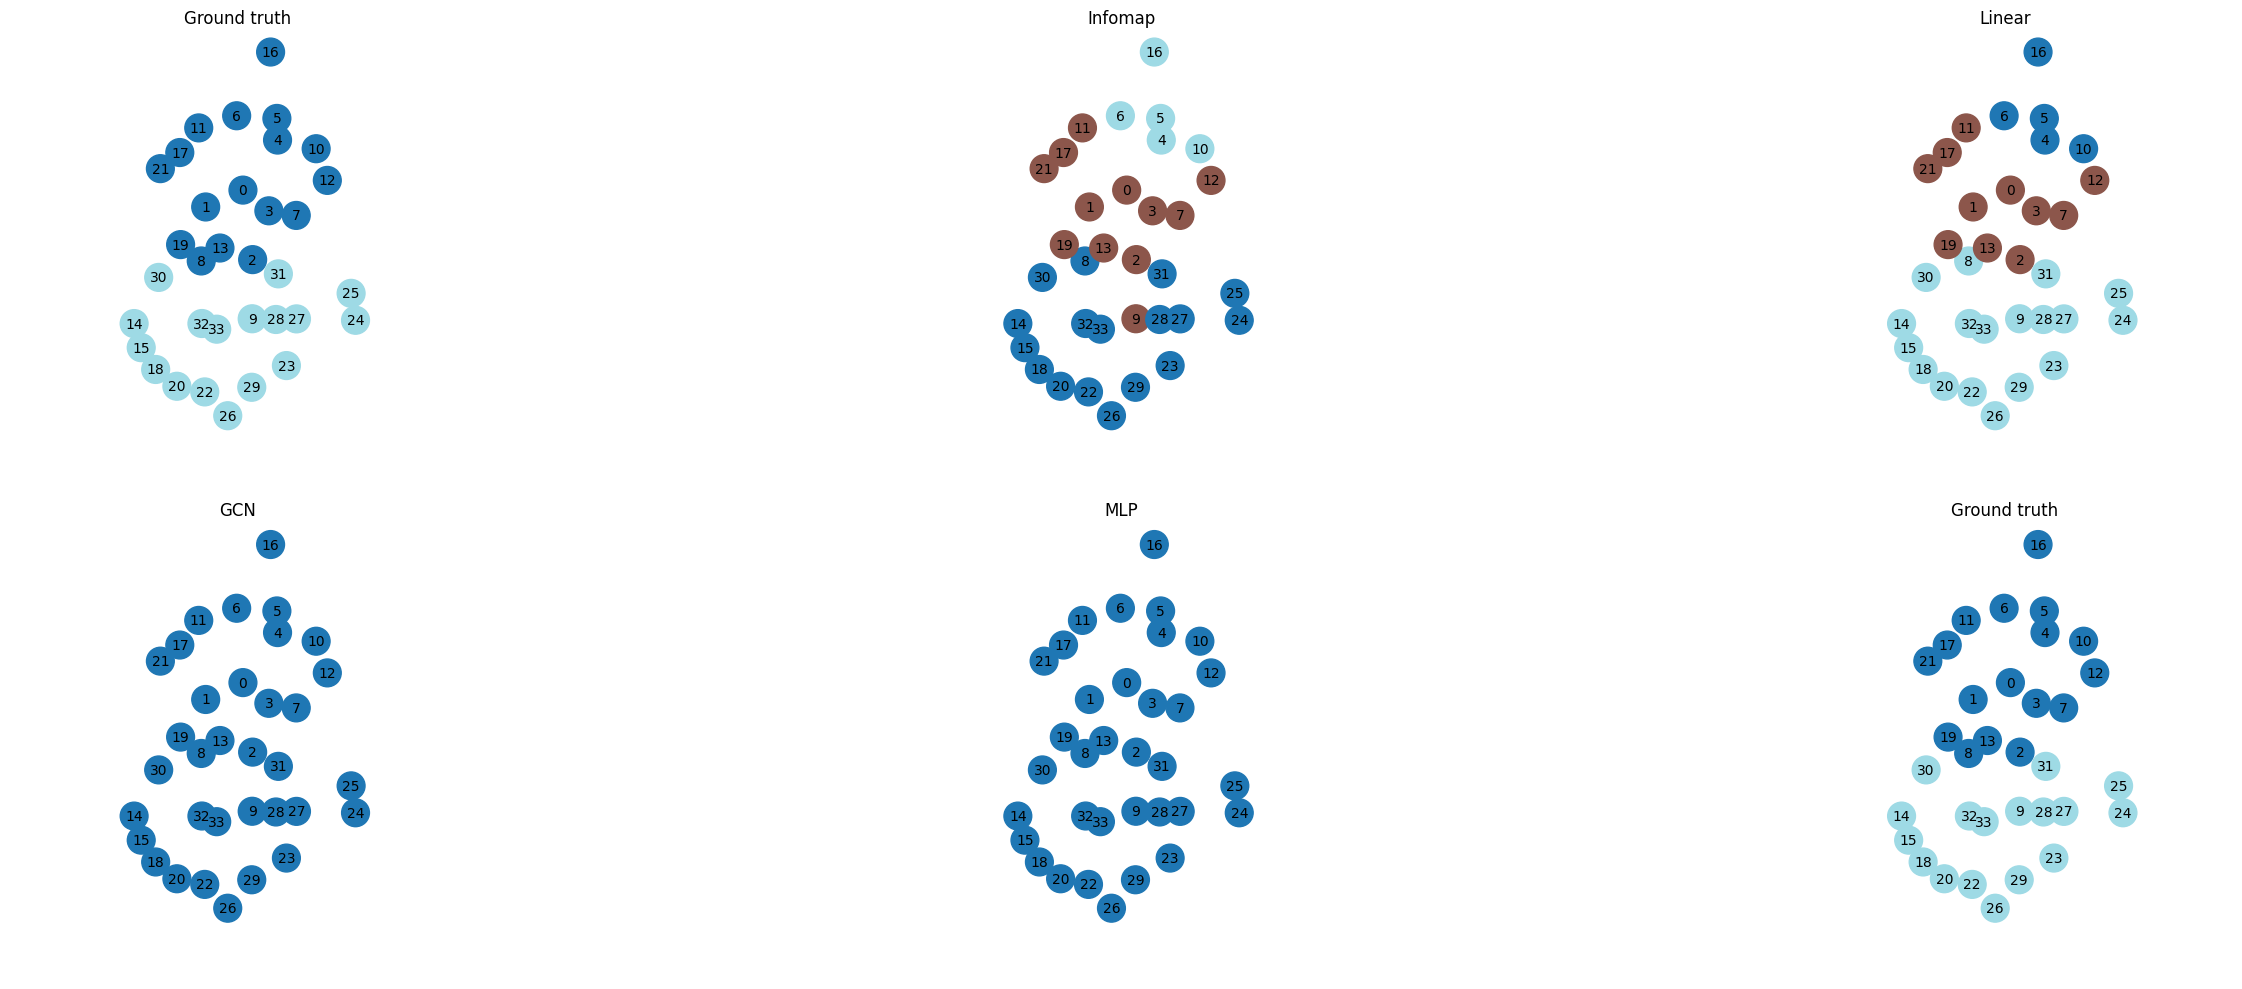

In [27]:
fig, axs = plt.subplots(2, 3, figsize=(30, 10))

pos = compute_pos(G, layout="kamada_kawai")

draw_nodes_only(G, y_true,             title="Ground truth", pos=pos, ax=axs[0][0])
draw_nodes_only(G, labels_infomap,     title="Infomap",      pos=pos, ax=axs[0][1])
draw_nodes_only(G, labels_linear_best, title="Linear",       pos=pos, ax=axs[0][2])
draw_nodes_only(G, labels_gcn_best,    title="GCN",          pos=pos, ax=axs[1][0])
draw_nodes_only(G, labels_mlp_best,    title="MLP",          pos=pos, ax=axs[1][1])
draw_nodes_only(G, y_true,             title="Ground truth", pos=pos, ax=axs[1][2])

plt.tight_layout()
plt.show()


## Entropy-regularized training

To mitigate the collapse to the trivial one-cluster solution observed in the previous experiments, we introduce an entropy regularization term on the soft assignment matrix $S$.

At each epoch, the training objective becomes:

$L_{train} = L_{Neuromap} - \lambda H(S)$   

where:

- $H(S)$ is the mean entropy of the row distributions of $S$
- $\lambda$ is a weight scheduled during training

The entropy term encourages non-degenerate assignments in early training, preventing all nodes from collapsing into a single module.  
The entropy weight decays to zero over epochs, so the final solution is still guided primarily by the Neuromap objective.

This modification allows us to test whether the previous failures of MLP and GCN can be avoided via anti-collapse pressure.


In [28]:
# Entropy-regularized comparison: Linear vs MLP vs GCN 

import pandas as pd
from sklearn.metrics import adjusted_mutual_info_score

def weight_schedule(epoch, epochs, w_start, w_end, mode="exp"):
    if epochs <= 1:
        return float(w_end)
    if mode == "linear":
        t = epoch / (epochs - 1)
        return float(w_start + t * (w_end - w_start))
    elif mode == "exp":
        w_start = float(w_start)
        w_end = float(w_end)
        if w_start == 0.0:
            return 0.0
        r = (w_end / w_start) ** (1.0 / (epochs - 1))
        return float(w_start * (r ** epoch))
    else:
        raise ValueError("mode must be 'linear' or 'exp'")

def entropy_term(S, mode="bonus", eps=1e-12):
    """
    S: (N,K) row-stochastic.
    mode:
      - "bonus": returns mean entropy H(S); you maximize it => subtract in loss.
      - "kl_uniform": returns mean KL(S||U); you minimize it => add in loss.
    """
    S_ = S.clamp_min(eps)
    H = -(S_ * torch.log(S_)).sum(dim=1).mean()
    if mode == "bonus":
        return H
    elif mode == "kl_uniform":
        K = S.size(1)
        return (-H + np.log(K))  # KL(S||U) = -H + logK
    else:
        raise ValueError("entropy_mode must be 'bonus' or 'kl_uniform'")

@torch.no_grad()
def hard_codelength_from_labels(F, p, labels, device):
    labels = torch.as_tensor(labels, device=device, dtype=torch.long)
    uniq = torch.unique(labels)
    remap = {int(old): i for i, old in enumerate(uniq.tolist())}
    labels01 = torch.tensor([remap[int(x)] for x in labels.tolist()], device=device, dtype=torch.long)

    S_hard = labels_to_S(labels01, num_clusters=len(uniq), device=device)
    L_full = neuromap_loss(F, p, S_hard, omit_constant_term=False).item()
    return float(L_full), int(len(uniq))

def train_neuromap_one_run(
    model,
    F, p, A, X,
    lr=1e-2, epochs=3000, patience=200, seed=27,
    temp_start=2.0, temp_end=0.7, temp_decay="exp",
    omit_constant_term=True,
    select_by_full_codelength=False,
    log_every=500,

    # entropy regularization
    ent_start=0.0, ent_end=0.0, ent_decay="exp",
    entropy_mode="bonus",
):
    """
    Generic trainer: model(A,X)->logits. Works for Linear, MLP (ignores A), and GCN.
    Returns best_S and history.
    """
    set_all_seeds(seed, deterministic=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best = {"score": float("inf"), "epoch": -1, "S": None}
    no_improve = 0
    history = {"loss_train": [], "score": [], "entropy_w": [], "entropy_val": [],
               "best_epoch": None, "best_score": None, "time_sec": None}

    t0 = time.time()

    for epoch in range(epochs):
        model.train()
        opt.zero_grad()

        logits = model(A, X)
        temp = temp_schedule(epoch, epochs, temp_start, temp_end, mode=temp_decay)
        S = torch.softmax(logits / temp, dim=1)

        L_nm = neuromap_loss(F, p, S, omit_constant_term=omit_constant_term)

        w_ent = weight_schedule(epoch, epochs, ent_start, ent_end, mode=ent_decay)
        if w_ent != 0.0:
            ent_val = entropy_term(S, mode=entropy_mode)
            L_train = (L_nm - (w_ent * ent_val)) if entropy_mode == "bonus" else (L_nm + (w_ent * ent_val))
        else:
            ent_val = torch.tensor(0.0, device=X.device)
            L_train = L_nm

        L_train.backward()
        opt.step()

        L_train_val = float(L_train.item())
        history["loss_train"].append(L_train_val)
        history["entropy_w"].append(float(w_ent))
        history["entropy_val"].append(float(ent_val.item()))

        if select_by_full_codelength:
            with torch.no_grad():
                score = float(neuromap_loss(F, p, S, omit_constant_term=False).item())
        else:
            score = L_train_val
        history["score"].append(score)

        if score < best["score"] - 1e-12:
            best = {"score": score, "epoch": epoch, "S": S.detach().clone()}
            no_improve = 0
        else:
            no_improve += 1

        if (epoch % log_every == 0) or (epoch == epochs - 1):
            print(
                f"epoch {epoch:4d} | temp {temp:.3f} | w_ent {w_ent:.2e} | "
                f"train {L_train_val:.6f} | best {best['score']:.6f} | no_improve {no_improve}"
            )

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best epoch {best['epoch']})")
            break

    history["time_sec"] = time.time() - t0
    history["best_epoch"] = best["epoch"]
    history["best_score"] = best["score"]
    return best["S"], history

def train_and_eval_neuromap(
    model_ctor, name,
    F, p, X,
    A_for_model,
    device,
    y_true=None,
    restarts=5,
    lr=1e-2, epochs=3000, patience=200,
    temp_start=2.0, temp_end=0.7, temp_decay="exp",
    base_seed=27,

    # entropy knobs
    ent_start=0.0, ent_end=0.0, ent_decay="exp",
    entropy_mode="bonus",
):
    best = {"L_full": float("inf"), "labels": None, "seed": None}
    t0 = time.time()

    for r in range(restarts):
        run_seed = base_seed + 1000 + r
        model = model_ctor().to(device)

        best_S, _ = train_neuromap_one_run(
            model=model,
            F=F, p=p,
            A=A_for_model,
            X=X,
            lr=lr, epochs=epochs, patience=patience, seed=run_seed,
            temp_start=temp_start, temp_end=temp_end, temp_decay=temp_decay,
            omit_constant_term=True,
            select_by_full_codelength=False,
            log_every=999999,

            ent_start=ent_start, ent_end=ent_end, ent_decay=ent_decay,
            entropy_mode=entropy_mode,
        )

        labels = torch.argmax(best_S, dim=1).detach().cpu().numpy()
        L_full, _ = hard_codelength_from_labels(F, p, labels, device=device)

        if L_full < best["L_full"]:
            best.update({"L_full": L_full, "labels": labels, "seed": run_seed})


    t1 = time.time()

    labels_best = best["labels"]
    L_hard, M_used = hard_codelength_from_labels(F, p, labels_best, device=device)
    AMI = float(adjusted_mutual_info_score(y_true, labels_best)) if y_true is not None else None

    result = {
        "method": name,
        "|M|": M_used,
        "L_hard": L_hard,
        "runtime_sec": t1 - t0,
        "AMI": AMI,
        "best_seed": best["seed"],
    }

    return result, labels_best


# run
results = []

ENT_START = 0.8
ENT_END   = 0.0
ENT_DECAY = "exp"
ENT_MODE  = "bonus"

res_lin, labels_lin = train_and_eval_neuromap(
    model_ctor=lambda: LinearNeuromap(in_dim=X.shape[1], num_clusters=s),
    name="Neuromap-Linear (+entropy)",
    F=F_mat, p=p, X=X,
    A_for_model=A,
    device=device,
    y_true=y_true,
    restarts=10,
    lr=1e-2, epochs=3000, patience=200,
    temp_start=2.0, temp_end=0.7, temp_decay="exp",
    base_seed=seed,
    ent_start=ENT_START, ent_end=ENT_END, ent_decay=ENT_DECAY, entropy_mode=ENT_MODE
)
results.append(res_lin)

res_mlp, labels_mlp = train_and_eval_neuromap(
    model_ctor=lambda: MLPNeuromap(in_dim=X.shape[1], hidden_dim=32, num_clusters=s),
    name="Neuromap-MLP (+entropy)",
    F=F_mat, p=p, X=X,
    A_for_model=A,   # ignored by MLP
    device=device,
    y_true=y_true,
    restarts=10,
    lr=1e-2, epochs=3000, patience=200,
    temp_start=2.0, temp_end=0.7, temp_decay="exp",
    base_seed=seed,
    ent_start=ENT_START, ent_end=ENT_END, ent_decay=ENT_DECAY, entropy_mode=ENT_MODE
)
results.append(res_mlp)

A_norm = normalize_adjacency(A)

res_gcn, labels_gcn = train_and_eval_neuromap(
    model_ctor=lambda: GCNNeuromap(in_dim=X.shape[1], hidden_dim=32, num_clusters=s),
    name="Neuromap-GCN (+entropy)",
    F=F_mat, p=p, X=X,
    A_for_model=A_norm,
    device=device,
    y_true=y_true,
    restarts=5,
    lr=5e-3, epochs=4000, patience=300,
    temp_start=2.0, temp_end=0.7, temp_decay="exp",
    base_seed=seed,
    ent_start=ENT_START, ent_end=ENT_END, ent_decay=ENT_DECAY, entropy_mode=ENT_MODE
)
results.append(res_gcn)

df = pd.DataFrame(results).sort_values("L_hard")
df


epoch    0 | temp 2.000 | w_ent 8.00e-01 | train -0.039786 | best -0.039786 | no_improve 0
epoch 2999 | temp 0.700 | w_ent 0.00e+00 | train -0.295100 | best -0.295100 | no_improve 10
epoch    0 | temp 2.000 | w_ent 8.00e-01 | train -0.039526 | best -0.039526 | no_improve 0
epoch 2999 | temp 0.700 | w_ent 0.00e+00 | train -0.295099 | best -0.295100 | no_improve 6
epoch    0 | temp 2.000 | w_ent 8.00e-01 | train -0.038260 | best -0.038260 | no_improve 0
epoch 2999 | temp 0.700 | w_ent 0.00e+00 | train -0.295102 | best -0.295102 | no_improve 4
epoch    0 | temp 2.000 | w_ent 8.00e-01 | train -0.037996 | best -0.037996 | no_improve 0
epoch 2999 | temp 0.700 | w_ent 0.00e+00 | train -0.295100 | best -0.295100 | no_improve 18
epoch    0 | temp 2.000 | w_ent 8.00e-01 | train -0.038427 | best -0.038427 | no_improve 0
epoch 2999 | temp 0.700 | w_ent 0.00e+00 | train -0.295099 | best -0.295099 | no_improve 7
epoch    0 | temp 2.000 | w_ent 8.00e-01 | train -0.039202 | best -0.039202 | no_improve

,method,|M|,L_hard,runtime_sec,AMI,best_seed
1,Neuromap-MLP (+entropy),2,4.408901,21.017651,0.669913,1028
0,Neuromap-Linear (+entropy),2,4.409322,56.283260,0.833466,1027
2,Neuromap-GCN (+entropy),1,4.704423,3.568670,0.000000,1030


### Results with entropy regularization

Adding entropy regularization substantially changes the behavior of the Linear and MLP models.

Both Neuromap-Linear (+entropy) and Neuromap-MLP (+entropy) now avoid the trivial collapse and recover a meaningful two-module partition ($|M| = 2$). That recalls the real partition of the system. 
Their hard codelengths are very close (≈ 4.409), slightly above Infomap but significantly below the one-cluster baseline (4.704).  
The AMI scores confirm that both models capture the true split structure, with Linear achieving higher agreement (AMI ≈ 0.83) and MLP slightly lower (AMI ≈ 0.67).

In contrast, Neuromap-GCN (+entropy) still collapses to the one-cluster solution ($|M| = 1$), with codelength equal to the trivial baseline and AMI = 0.  
This indicates that, in this simplified setup, entropy regularization alone is not sufficient to prevent oversmoothing and assignment collapse in the GCN.


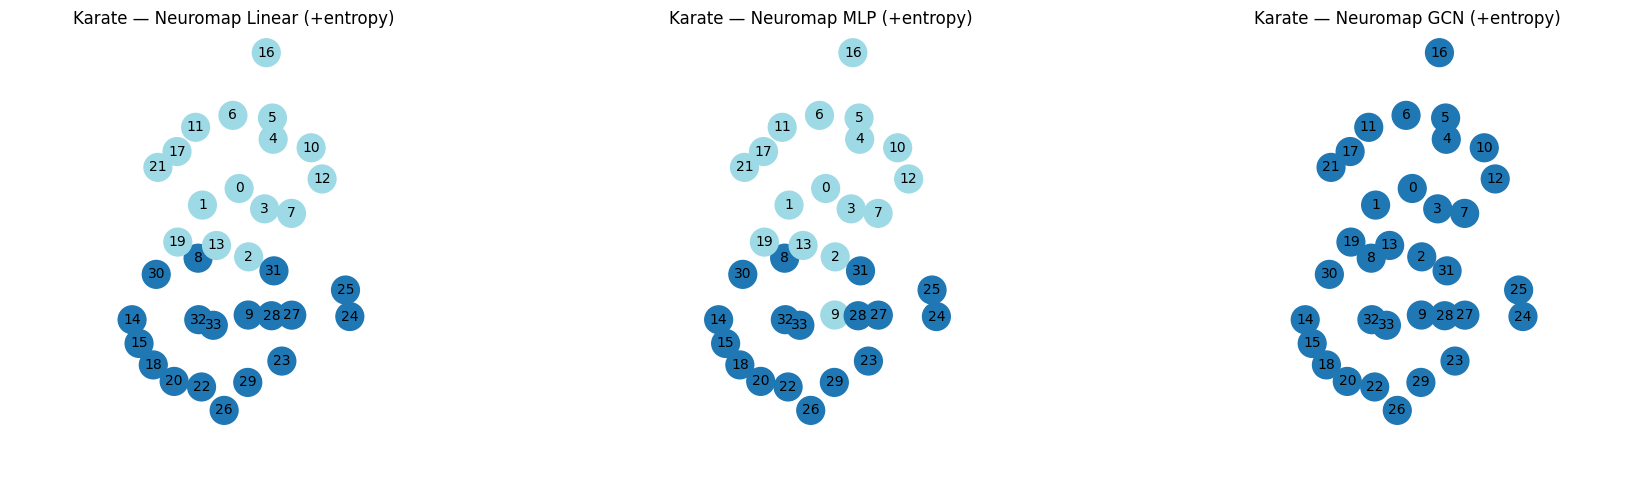

In [29]:
# Partition comparison 

labels_linear_ent = labels_lin
labels_mlp_ent    = labels_mlp
labels_gcn_ent    = labels_gcn

# Create figure with 3 panels
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

pos = compute_pos(G, layout="kamada_kawai")

draw_nodes_only(
    G, labels_linear_ent,
    title="Karate — Neuromap Linear (+entropy)",
    pos=pos, ax=axs[0]
)

draw_nodes_only(
    G, labels_mlp_ent,
    title="Karate — Neuromap MLP (+entropy)",
    pos=pos, ax=axs[1]
)

draw_nodes_only(
    G, labels_gcn_ent,
    title="Karate — Neuromap GCN (+entropy)",
    pos=pos, ax=axs[2]
)

plt.tight_layout()
plt.show()


## Extension to the Football network

After validating the implementation on small graphs, we apply the same models to the more complex Football dataset.

We report results from:

1. Our local Neuromap implementation  
2. The official implementation released by the authors  

This allows us to separate the implementation limitation caused by the minimal environment we are currently working with from the theoretical model capacity.


In [30]:
# load football graph 
G = nx.read_gml("./network/football.gml")
G = nx.convert_node_labels_to_integers(G)

nodes = list(G.nodes())
n = len(nodes)

# ground truth labels aligned with node order
y_true = np.array([G.nodes[i]["value"] for i in nodes])

# build adjacency A  on your device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
A = torch.tensor(nx.to_numpy_array(G, nodelist=nodes, dtype=float),
                 dtype=torch.float32, device=device)

# choose node features X 
deg = A.sum(dim=1, keepdim=True)
X = torch.randn(n, 32, device=device)
# --- 3) compute p and F_mat using your existing functions ---
alpha = 0.15
max_iter = 5000
tol = 1e-12
p, T, d_in, w_tot = compute_visit_rates(A, alpha, max_iter, tol)
F_mat, _ = compute_flow_matrix(A, T, p, alpha=alpha)

# pick s (num clusters) 
s = int(len(np.unique(y_true)))   # match ground truth count

seed = 27
print(f"Football loaded: n={n}, s={s}, X_dim={X.shape[1]}, device={device}")


Football loaded: n=115, s=12, X_dim=32, device=cpu


In [31]:
# Infomap + adjacency normalization

def infomap_partition_labels_aligned(G, node_to_idx):
    """
    Infomap hard labels aligned with the node ordering used in A/X/F_mat.
    """
    from infomap import Infomap

    im = Infomap("--silent")
    im.add_networkx_graph(G)
    im.run()

    n = len(node_to_idx)
    labels = np.zeros(n, dtype=int)

    for node in im.tree:
        if node.is_leaf:
            idx = node_to_idx[node.node_id]  # node_id is the NetworkX node key
            labels[idx] = node.module_id

    # relabel modules to 0..K-1
    uniq = np.unique(labels)
    remap = {old: i for i, old in enumerate(uniq)}
    labels = np.array([remap[x] for x in labels], dtype=int)
    return labels

@torch.no_grad()
def hard_codelength_from_labels(F, p, labels, device):
    """
    Full Neuromap codelength on a HARD partition (one-hot S).
    Returns (L_full, M_used).
    """
    labels = torch.as_tensor(labels, device=device, dtype=torch.long)
    uniq = torch.unique(labels)
    remap = {int(old): i for i, old in enumerate(uniq.tolist())}
    labels01 = torch.tensor([remap[int(x)] for x in labels.tolist()], device=device, dtype=torch.long)

    S_hard = labels_to_S(labels01, num_clusters=len(uniq), device=device)
    L_full = float(neuromap_loss(F, p, S_hard, omit_constant_term=False).item())
    return L_full, int(len(uniq))

def normalize_adjacency_fast(A):
    """
    Symmetric normalization: D^{-1/2} (A+I) D^{-1/2}, without building diag matrices.
    """
    I = torch.eye(A.shape[0], device=A.device, dtype=A.dtype)
    A_hat = A + I
    deg = A_hat.sum(dim=1)
    deg_inv_sqrt = torch.rsqrt(deg.clamp_min(1e-12))
    return deg_inv_sqrt.unsqueeze(1) * A_hat * deg_inv_sqrt.unsqueeze(0)


In [32]:
# Infomap baseline on Football

node_to_idx = {u: i for i, u in enumerate(nodes)}  # must match A/X/F_mat ordering

t0 = time.time()
labels_infomap = infomap_partition_labels_aligned(G, node_to_idx)
t1 = time.time()

L_im, M_im = hard_codelength_from_labels(F_mat, p, labels_infomap, device=device)
AMI_im = float(adjusted_mutual_info_score(y_true, labels_infomap))

print(f"Infomap |M|={M_im} | L_hard={L_im:.6f} | AMI={AMI_im:.4f} | time={t1-t0:.2f}s")


Infomap |M|=11 | L_hard=5.464798 | AMI=0.8844 | time=0.01s


In [33]:
# Linear Neuromap (no Infomap imitation / no warm-start)

import numpy as np
import torch
import torch.nn.functional as F
import inspect
import time
from sklearn.metrics import adjusted_mutual_info_score

L_im, M_im = hard_codelength_from_labels(F_mat, p, labels_infomap, device=device)
AMI_im = float(adjusted_mutual_info_score(y_true, labels_infomap))
print(f"Infomap baseline: AMI={AMI_im:.4f} |M|={M_im} L_hard={L_im:.6f}")


def call_model(model, A_for_model, X):
    sig = inspect.signature(model.forward)
    params = [p for p in sig.parameters.keys() if p != "self"]
    if len(params) == 1:
        return model(X)
    try:
        return model(A_for_model, X)
    except TypeError:
        return model(X, A_for_model)


def out_to_probs(out, temp=1.0, eps=1e-12):
    if out.dim() != 2:
        raise ValueError(f"Expected [n,s] output, got {tuple(out.shape)}")

    row_sums = out.sum(dim=1)
    if (out.min() >= 0.0) and (out.max() <= 1.0) and torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-3):
        return out.clamp_min(eps)

    return torch.softmax(out / max(temp, 1e-6), dim=1).clamp_min(eps)


def train_linear_neuromap_normal(
    in_dim,
    s,
    A, X,
    F_mat, p,
    y_true,
    lr=1e-2,
    epochs=6000,
    temp_start=2.5,
    temp_end=0.95,
    weight_decay=1e-4,
    track_every=200,
    patience=12,
    omit_constant_term=True,
    seed=0,
):
    torch.manual_seed(seed)
    model = LinearNeuromap(in_dim=in_dim, num_clusters=s).to(X.device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # best checkpoint by L_hard (no "safe" bias toward Infomap)
    best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    best_labels = None
    best_L = float("inf")
    best_AMI = float("-inf")
    no_improve = 0
    t0 = time.time()

    for epoch in range(epochs):
        frac = epoch / max(epochs - 1, 1)
        temp = temp_start * ((temp_end / temp_start) ** frac)

        model.train()
        opt.zero_grad()

        out = call_model(model, A, X)
        S = out_to_probs(out, temp=temp)

        loss = neuromap_loss(F_mat, p, S, omit_constant_term=omit_constant_term)
        loss.backward()
        opt.step()

        if (epoch + 1) % track_every == 0 or (epoch + 1) == epochs:
            model.eval()
            with torch.no_grad():
                out_eval = call_model(model, A, X)
                S_eval = out_to_probs(out_eval, temp=temp_end)
                labels = torch.argmax(S_eval, dim=1).cpu().numpy()

            L_hard, M_used = hard_codelength_from_labels(F_mat, p, labels, device=device)
            AMI = float(adjusted_mutual_info_score(y_true, labels))

            improved = (L_hard < best_L - 1e-9)
            if improved:
                best_L = L_hard
                best_AMI = AMI
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                best_labels = labels.copy()
                no_improve = 0
            else:
                no_improve += 1

            elapsed = time.time() - t0
            print(f"[linear] seed {seed:3d} | ep {epoch+1:4d}/{epochs} temp {temp:.3f} loss {float(loss):.6f} | "
                  f"L_hard {L_hard:.6f} |M| {M_used:3d} AMI {AMI:.4f} | best_L {best_L:.6f} | no_improve {no_improve} | {elapsed:.1f}s")

            if no_improve >= patience:
                break

    model.load_state_dict(best_state, strict=True)
    return model, best_labels, best_L, best_AMI

# Choose s
s = int(len(np.unique(labels_infomap))*2) 
print("NORMAL training with s =", s)

RESTARTS = 3
base_seed = 123
best_overall = dict(L=float("inf"), AMI=float("-inf"), seed=None, labels=None, model=None)

for r in range(RESTARTS):
    run_seed = base_seed + r
    model_r, labels_r, L_r, AMI_r = train_linear_neuromap_normal(
        in_dim=X.shape[1],
        s=s,
        A=A, X=X,
        F_mat=F_mat, p=p,
        y_true=y_true,
        lr=1e-2,
        epochs=3000,
        temp_start=2.5,
        temp_end=0.95,
        track_every=200,
        patience=12,
        omit_constant_term=True,
        seed=run_seed,
    )

    if labels_r is None:
        continue

    if L_r < best_overall["L"] - 1e-9:
        best_overall.update(L=L_r, AMI=AMI_r, seed=run_seed, labels=labels_r, model=model_r)

print("\n=== NORMAL Linear Neuromap (best restart) ===")
print(f"Infomap: AMI={AMI_im:.4f} |M|={M_im} L_hard={L_im:.6f}")
if best_overall["labels"] is None:
    print("LinearNeuromap: no valid checkpoint produced (unexpected) — check training for NaNs.")
else:
    L_best, M_best = hard_codelength_from_labels(F_mat, p, best_overall["labels"], device=device)
    AMI_best = float(adjusted_mutual_info_score(y_true, best_overall["labels"]))
    print(f"Linear:  AMI={AMI_best:.4f} |M|={M_best} L_hard={L_best:.6f} (seed={best_overall['seed']})")

labels_linear = best_overall["labels"]  


Infomap baseline: AMI=0.8844 |M|=11 L_hard=5.464798
NORMAL training with s = 22


/tmp/ipykernel_173283/1591227441.py:101: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f"[linear] seed {seed:3d} | ep {epoch+1:4d}/{epochs} temp {temp:.3f} loss {float(loss):.6f} | "


[linear] seed 123 | ep  200/3000 temp 2.345 loss 0.471401 | L_hard 7.203547 |M|   9 AMI 0.3697 | best_L 7.203547 | no_improve 0 | 0.4s
[linear] seed 123 | ep  400/3000 temp 2.198 loss 0.288918 | L_hard 7.097318 |M|  10 AMI 0.4154 | best_L 7.097318 | no_improve 0 | 1.0s
[linear] seed 123 | ep  600/3000 temp 2.061 loss 0.268866 | L_hard 7.097318 |M|  10 AMI 0.4154 | best_L 7.097318 | no_improve 1 | 1.6s
[linear] seed 123 | ep  800/3000 temp 1.932 loss 0.262429 | L_hard 7.097318 |M|  10 AMI 0.4154 | best_L 7.097318 | no_improve 2 | 2.1s
[linear] seed 123 | ep 1000/3000 temp 1.811 loss 0.249667 | L_hard 7.086887 |M|  10 AMI 0.4163 | best_L 7.086887 | no_improve 0 | 2.5s
[linear] seed 123 | ep 1200/3000 temp 1.698 loss 0.246124 | L_hard 7.082775 |M|  10 AMI 0.4192 | best_L 7.082775 | no_improve 0 | 3.0s
[linear] seed 123 | ep 1400/3000 temp 1.592 loss 0.230395 | L_hard 7.069600 |M|  10 AMI 0.4215 | best_L 7.069600 | no_improve 0 | 3.4s
[linear] seed 123 | ep 1600/3000 temp 1.492 loss 0.2298


**Simplified environment implementation results**

In our simplified implementation, the Linear model remains the only architecture that produces a non-trivial partition.

Best Linear result:

- $|M| = 12$
- $L_{hard} = 6.838049$
- AMI = 0.5122

For comparison:

- Infomap: $|M| = 11$, $L_{hard} = 5.46480$, AMI = 0.8844

The gap in codelength and AMI indicates that while the Linear Neuromap model captures the structure, it does not reach the compression quality or ground-truth alignment of Infomap. This reflects the limitation of the local implementation of the model which needs an accurate tuning to work properly.


**Authors’ official implementation results**

Using the official Neuromap code, all architectures recover non-trivial partitions:
- Linear: Ami = 41.9, |M|= 4
- Linear: MLP = 65.3, |M|= 6
- Linear: GIN = 69.2, |M|= 6
- Linear: GCN = 78.5, |M|= 8
- Linear: SAGE = 77.2, |M|= 8


We note that all neural architectures produce meaningful multi-cluster partitions due to the more advanced implementations, and GCN and GraphSAGE achieve the strongest agreement with ground truth, in agreement to the paper findings and Performance clearly improves with topology-aware architectures.

The contrast between our implementation and the authors’ code highlights an important point:

The Neuromap objective alone is not sufficient to guarantee good partitions in practice if it is not backed by a strong architecture.


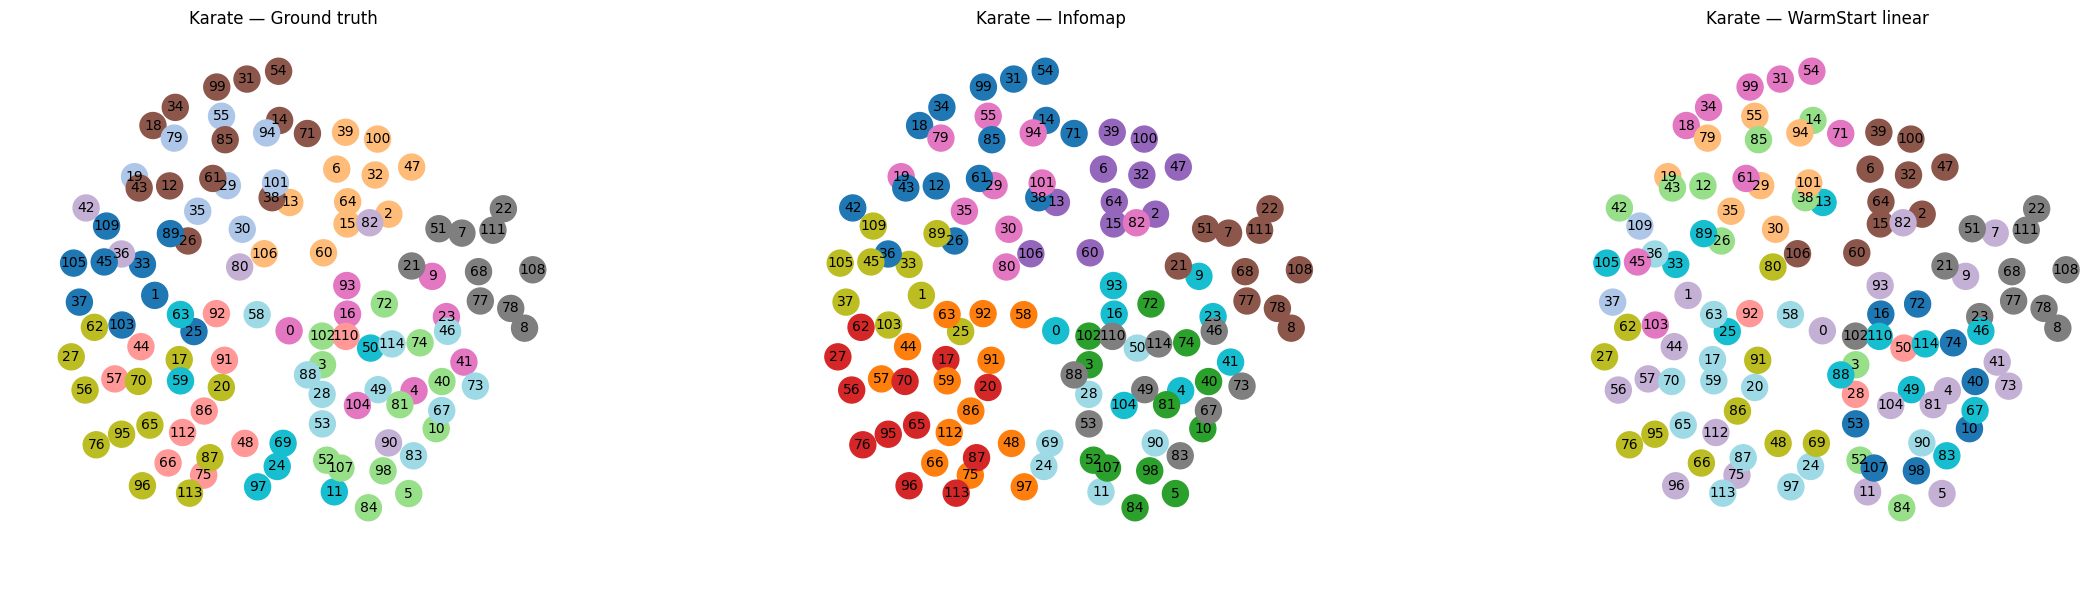

In [35]:
import matplotlib.pyplot as plt

# Make sure these exist from your run:
# G, y_true, labels_infomap, labels_ft

fig, axs = plt.subplots(1, 3, figsize=(24, 6))

# layout once
pos = compute_pos(G, layout="kamada_kawai")

draw_nodes_only(G, y_true,        title="Karate — Ground truth", pos=pos, ax=axs[0], node_size=350, with_labels=True)
draw_nodes_only(G, labels_infomap, title="Karate — Infomap",      pos=pos, ax=axs[1], node_size=350, with_labels=True)
draw_nodes_only(G, labels_linear,      title="Karate — WarmStart linear", pos=pos, ax=axs[2], node_size=350, with_labels=True)

plt.tight_layout()
plt.show()


![](./fig/models_authors_code.png)

## Conclusion

In our simplified implementation, the Linear model proves to be the most robust architecture: it consistently avoids collapse and recovers meaningful partitions, although its performance remains limited compared to Infomap. In contrast, higher-capacity models such as MLP and GCN are unstable in this setting and frequently converge to trivial one-cluster solutions.

When using the authors’ full implementation, the picture changes significantly. With proper stabilization mechanisms and architectural tuning, expressive models such as GCN, GraphSAGE, and GIN successfully recover non-trivial and structurally relevant partitions, often outperforming simpler models.

This comparison highlights a key aspect: while the Neuromap objective is theoretically well-founded and information-theoretically principled, its practical effectiveness depends critically on training dynamics, regularization, and architectural design choices.